# EXERCISE 2 - SENTIMENT ANALYSIS CLASSIFICATION TASK WITH CNNs

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gzip
import tarfile
from sklearn.datasets import load_files

In [2]:
# Download Data
!wget https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
!tar xvzf aclImdb_v1.tar.gz > /dev/null

--2024-03-13 08:51:14--  https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
Resolving ai.stanford.edu (ai.stanford.edu)... 171.64.68.10
Connecting to ai.stanford.edu (ai.stanford.edu)|171.64.68.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84125825 (80M) [application/x-gzip]
Saving to: ‘aclImdb_v1.tar.gz’

aclImdb_v1.tar.gz   100%[===================>]  80.23M  13.9MB/s    in 7.0s    

2024-03-13 08:51:22 (11.4 MB/s) - ‘aclImdb_v1.tar.gz’ saved [84125825/84125825]



In [3]:
# # Load files in google collab


# from sklearn.datasets import load_files

# movies_train = load_files(container_path="aclImdb_v1/aclImdb/train", encoding="utf-8")
# movies_test = load_files(container_path="aclImdb_v1/aclImdb/test", encoding="utf-8")


In [4]:
from sklearn.datasets import load_files

movies_train = load_files(container_path="/content/aclImdb/train", encoding="utf-8")
movies_test = load_files(container_path="/content/aclImdb/test", encoding="utf-8")

In [5]:
# from sklearn.datasets import load_files
# movies_train = load_files(container_path="//home/aclImdb/train", encoding="utf-8")
# movies_test = load_files(container_path="//home/aclImdb/test", encoding="utf-8")
# # print(type(movies_train))

In [6]:
# Transform train dataset into a dataframe
data_train = {'reviews': movies_train.data, 'sentiment': movies_train.target}
df_train = pd.DataFrame(data_train)

# Transform test dataset into a dataframe
data_test = {'reviews': movies_test.data, 'sentiment': movies_test.target}
df_test = pd.DataFrame(data_test)

del movies_train, movies_test # free memory

print(df_train.iloc[:10])
print('----------------------------------------------------------------------------------------')
print(df_test.iloc[:10])

                                             reviews  sentiment
0  Full of (then) unknown actors TSF is a great b...          2
1  Amount of disappointment I am getting these da...          2
2  The future, we are told, are what we make of i...          2
3  Dan Katzir has produced a wonderful film that ...          1
4  If you want Scream or anything like the big-st...          1
5  Although its mold of 1949 appears somewhat mel...          2
6  Gloomy Sunday - Ein Lied von Liebe und Tod dir...          2
7  This movie was ridiculous. The plot is complet...          2
8  Why was this movie made? No doubt to sucker in...          2
9  Outlandish premise that rates low on plausibil...          0
----------------------------------------------------------------------------------------
                                             reviews  sentiment
0  Don't hate Heather Graham because she's beauti...          1
1  I don't know how this movie has received so ma...          0
2  I caught thi

Remove label 2

In [7]:
# Drop rows where 'sentiment' is 2 from train & test sets
df_train = df_train[df_train['sentiment'] != 2]
df_test = df_test[df_test['sentiment'] != 2]


df_test = df_test.reset_index(drop=True)
df_train = df_train.reset_index(drop=True)

# Define the train dataset with 5000 rows by test set
df_train = pd.concat([df_train, df_test[:5000]])

print(f'The size of training set is: {len(df_train)}')
print(f'The size of test set is: {len(df_test[5000:])}')

The size of training set is: 30000
The size of test set is: 20000


In [8]:
from sklearn.utils import shuffle

# Shuffle dataframes because they are sorted.
df_train = shuffle(df_train)
df_train.reset_index(inplace=True, drop=True)
df_test = shuffle(df_test)
df_test.reset_index(inplace=True, drop=True)

df_train.head()

,reviews,sentiment
0,"I don't know why, but when I am asked about ba...",0
1,"I was thirteen years old, when I saw this movi...",0
2,I've read plenty of Jane Austen in my time and...,0
3,I found myself watching Sex Lives Of The Potat...,0
4,Although The Notorious Bettie Page is well act...,1


In [9]:
X_train = df_train.reviews
y_train = df_train.sentiment

In [10]:
# Split dev and test data
from sklearn.model_selection import train_test_split

X_dev, X_test, y_dev, y_test = train_test_split(df_test.reviews[5000:], df_test.sentiment[5000:], test_size=0.5, random_state=42)
print(f"Number of observations in dev set: {X_dev.shape[0]}")
print(f"Number of observations in test set: {X_test.shape[0]}")

Number of observations in dev set: 10000
Number of observations in test set: 10000


# Preprocessing

* Replace non-word characters and numbers with empty string.
* Substitute multiple spaces with single space.
* Convert to lowercase.
* Remove stop words.
* Stemming with WordNetLemmatizer.

In [11]:
# Imports we need for preprocessing
import re
import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer

stemmer = WordNetLemmatizer()

# Import stop words for preprocessing
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [12]:
def preprocess(contents):
  """
    Preprocesses a list of texts by removing non-word characters, single characters, extra spaces,
    converting to lowercase, splitting into words, lemmatizing, and reconstructing the documents.

    Parameters:
    - contents (list): A list of texts to be preprocessed.

    Returns:
    - pd.Series: A Pandas Series containing preprocessed documents.
    """

  docs = []

  for doc in contents:

      # Remove non-word (special) characters such as punctuation, numbers etc
      document = re.sub(r'\W', ' ', str(doc))

      # Remove HTML <BR>
      document = re.sub(r'\s+br\s+',' ', str(document))

      # Remove all single characters
      document = re.sub(r'\s+[a-zA-Z]\s+', ' ', document)

      # Remove numbers
      document = re.sub(r'\b\d+\b', ' ', document)

      # Substitute multiple spaces with single space
      document = re.sub(r'\s+', ' ', document, flags=re.I) #re.I -> ignore case

      # Convert to Lowercase
      document = document.lower()

      # Split the document based on whitespaces (--> List of words)
      word_list = word_tokenize(document)

      # word_list = document.split()

      word_list = [word for word in word_list if word not in (stop_words)]

      # Lemmatization
      # word_list = [stemmer.lemmatize(word) for word in word_list]

      # # Reconstruct the document by joining the words on each whitespace
      document = ' '.join(word_list)

      # Append all documents into a list 'docs'
      docs.append(document)
  return pd.Series(docs)

In [13]:
# Preprocess texts
X_train = preprocess(X_train)
X_dev = preprocess(X_dev)
X_test = preprocess(X_test)

In [14]:
# Example of a preprocessed text
print(f'The non processed text:\n {df_train.reviews.iloc[10]}')
print('------------------------------------------------------------------------------------')
print('VS')
print('------------------------------------------------------------------------------------')
print(f'The processed text:\n {X_train[10]}')

The non processed text:
 I had high hopes for this film. I thought the premise interesting. I stuck through it, even though I found the acting, save Helena Bonham Carter, unremarkable. I kept hoping my time spent would pay off, but in the end I was left me wondering why they even bothered to make this thing. Maybe in George Orwell's version there is a message worth conveying. If this film accomplished anything, it has inspired me to read Orwell's classic. I find it hard to believe his tale could be as disappointing as this adaption. If the film maker's message is "the mundane life is worth living", well then, they've succeeded. I would recommend this film to no one; 101 minutes of my life wasted.
------------------------------------------------------------------------------------
VS
------------------------------------------------------------------------------------
The processed text:
 high hopes film thought premise interesting stuck even though found acting save helena bonham carter

In [ ]:
print(X_train.shape,X_dev.shape,X_test.shape)

(30000,) (10000,) (10000,)


## Baseline Model (Logistic Regression with  TF-IDF and SVD)

In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Use unigram & bi-gram tf*idf features
vectorizer = TfidfVectorizer(ngram_range=(1, 3),
                             max_features = 5000, sublinear_tf=True)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_dev_tfidf = vectorizer.transform(X_dev)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape, type(X_train_tfidf))

(30000, 5000) <class 'scipy.sparse._csr.csr_matrix'>


In [59]:
# Reduce dimensionality using SVD 5000 --> 1000
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=1000, random_state=4321)
X_train_svd = svd.fit_transform(X_train_tfidf)
X_dev_svd = svd.transform(X_dev_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

print(X_train_svd.shape, type(X_train_svd))

(30000, 1000) <class 'numpy.ndarray'>


In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve, auc
clf = LogisticRegression()
clf.fit(X_train_svd.tolist(), y_train)

# Validation set prediction
predictions = clf.predict(X_dev_svd.tolist())
print(f"\t\tClassification Report for developement set:\n\n {classification_report(y_dev, predictions)}")

# Test set prediction
predictions2 = clf.predict(X_test_svd.tolist())
print(f"\n\n\t\tClassification Report for testing set:\n\n {classification_report(y_test, predictions2)}")

		Classification Report for developement set:

               precision    recall  f1-score   support

           0       0.90      0.88      0.89      4976
           1       0.88      0.90      0.89      5024

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



		Classification Report for testing set:

               precision    recall  f1-score   support

           0       0.89      0.88      0.89      5003
           1       0.88      0.89      0.89      4997

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



### MLP Baseline-2

In [ ]:
# Import libraries
# Import libraries
import keras
from keras.layers import InputLayer
from keras.layers import Activation, Dropout, Dense, Input,BatchNormalization, Flatten, Embedding
from keras.models import Model, Sequential
from keras.optimizers import Adam
from keras.preprocessing.text import Tokenizer
# from keras.preprocessing.sequence import pad_sequences
from keras.callbacks import ModelCheckpoint, EarlyStopping, Callback
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split


def create_MLP_model(input_dim, activation_dense_layers):
    """
    Create a deep feed forward network with Dense layers
    Add techniques such as dropout and Batch Normalization
    :param input_dum: integer for the dimension of the input layer)
    :param  activation_dense_layers: string, for the activation function
    :return: class keras.src.engine

    """
    mlp_model = Sequential()

    # Add InputLayer with specified input dimension
    mlp_model.add(InputLayer(input_shape=(input_dim,)))

    # First Layer
    mlp_model.add(Dense(128, activation='relu'))
    mlp_model.add(BatchNormalization())
    mlp_model.add(Dropout(0.4))
    # Second Layer
    mlp_model.add(Dense(512, activation='relu'))
    mlp_model.add(BatchNormalization())
    mlp_model.add(Dropout(0.5))
    # Third Layer
    mlp_model.add(Dense(128, activation='relu'))
    mlp_model.add(BatchNormalization())
    mlp_model.add(Dropout(0.4))
    # Output Layer
    mlp_model.add(Dense(1, activation='sigmoid'))


    return mlp_model


In [ ]:
class Metrics(Callback):
    def __init__(self, valid_data):
        super(Metrics, self).__init__()
        self.validation_data = valid_data

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_predict_proba = self.model.predict(self.validation_data[0])
        val_predict = (val_predict_proba > 0.5).astype(int)  # Convert probabilities to classes

        val_targ = self.validation_data[1]

        _val_f1 = f1_score(val_targ, val_predict, average="binary")
        _val_recall = recall_score(val_targ, val_predict, average="binary")
        _val_precision = precision_score(val_targ, val_predict, average="binary")

        logs['val_f1'] = _val_f1
        logs['val_recall'] = _val_recall
        logs['val_precision'] = _val_precision
        print(" — val_f1: %.3f — val_precision: %.3f — val_recall: %.3f" % (_val_f1, _val_precision, _val_recall))


In [ ]:
from sklearn.metrics import f1_score, recall_score, precision_score

adam = Adam(learning_rate = 0.00004)

mlp = create_MLP_model(X_train_svd.shape[1],'relu')
mlp.compile(
    loss='binary_crossentropy',
    optimizer=adam,
    metrics=["accuracy"]
    )

# Build the model and print the structure of our model before training
mlp.build(X_train_svd.shape[1])  # We need to build our model in order to print the structure
print(mlp.summary())

# Add an early stopping callback to stop the epochs when we catch the best validation loss
early_stopping_callback = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss for early stopping
    patience=10,           # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restore best model weights when early stopping is triggered
)

# Callback to save the Keras model or model weights at some frequency.
MLP_checkpoint = ModelCheckpoint(
    'checkpoints/weights.hdf5',
    monitor='val_loss',
    mode='min',
    verbose=2,
    save_best_only=True,
    save_weights_only=True
    )

# Start our training
history = mlp.fit(
    X_train_svd,
    y_train,
    validation_data=(X_dev_svd, y_dev),
    batch_size=128,
    epochs=65,
    shuffle=True,
    callbacks=[early_stopping_callback]
)

### TOKENIZATION

In [72]:
def is_number(s):
    try:
        float(s)
        return True
    except ValueError:
        return False

In [75]:
%%capture
!pip install spacy
!python -m spacy download en_core_web_lg

In [76]:
import spacy
import string
import numpy as np
from tqdm import tqdm

nlp = spacy.load('en_core_web_lg', disable=["tagger", "parser", "ner", "lemmatizer"])
from spacy.lang.en.stop_words import STOP_WORDS
nlp.add_pipe('sentencizer')


# Create a function that uses spacy to tokenize sentences and returns a nested list of tokenized sentences
def tokenize_data (data):
  """
    Tokenize our data
    :param data: list of documents
    :return: nested list of the tokenized documents
    """
  data_tokenized = []
  for idx in tqdm(range(len(data))):
    doc = nlp(data[idx])
    tokens = []
    for sent in doc.sents:
      for tok in sent:
        if '\n' in tok.text or "\t" in tok.text or "--" in tok.text or "*" in tok.text or\
        tok.text.lower() in STOP_WORDS or tok.text in string.punctuation or\
          all(x in string.punctuation for x in tok.text) or is_number(tok.text):
          continue
        if tok.text.strip():
          tokens.append(tok.text.replace('"',"'").strip().lower())
    data_tokenized.append(tokens)
  return data_tokenized

X_train_tokenized = tokenize_data(X_train)
X_dev_tokenized = tokenize_data(X_dev)
X_test_tokenized = tokenize_data(X_test)



100%|██████████| 10000/10000 [01:49<00:00, 90.98it/s]


GET MAX SEQUENCE

In [77]:
mean_words = np.mean([len(x) for x in X_train_tokenized])
std_of_words = np.std([len(x) for x in X_train_tokenized])

# Get mean and std of sequence length on trainning set
print(f"Mean: {np.mean([len(x) for x in X_train_tokenized]): .2f}")
print(f"Std: {np.std([len(x) for x in X_train_tokenized]): .2f}")

Mean:  105.28
Std:  80.95


* LETS KEEP THE REVIEWS WITH MAX LENGTH= mean_words + (2 * std_of_word_counts)

In [78]:
print(f"{[len(x) for x in X_train_tokenized]}")

# Define a function that drops the rows not meeting the criteria
def estimate_max_seq_len(data_tokenized, targets, mean_w=mean_words, std_w=std_of_words):
    # Create a DataFrame to work with
    data = pd.DataFrame(columns=['data_tokenized', 'word_counts', 'targets'])

    # Assign the tokenized text to a column inside the dataframe
    data["data_tokenized"] =  data_tokenized
    # Assign the word counts for each row in a second column
    data["word_counts"] = [len(x) for x in data_tokenized]

    # Assign target variables
    data["targets"] = targets.tolist()

    display(data.head())

    # Custom formula of estimating the MAX_words_Length
    MAX_words_length = mean_w + 2*std_w

    # Drop the rows not meeting the criteria
    data = data[data.word_counts <= MAX_words_length]

    return [' '.join(x) for x in data.data_tokenized], data.targets

X_train, y_train = estimate_max_seq_len(X_train_tokenized, y_train)
# X_dev, y_dev = estimate_max_seq_len(X_dev_tokenized, y_dev)
# X_test, y_test = estimate_max_seq_len(X_test_tokenized, y_test)



[20, 48, 47, 97, 240, 183, 80, 61, 47, 72, 56, 53, 135, 72, 201, 331, 55, 157, 144, 69, 107, 213, 56, 89, 317, 49, 106, 166, 41, 170, 37, 101, 47, 136, 96, 44, 371, 49, 80, 60, 113, 88, 53, 36, 22, 53, 323, 143, 44, 54, 79, 427, 101, 76, 54, 97, 80, 282, 183, 59, 211, 166, 62, 39, 52, 98, 53, 60, 102, 128, 158, 84, 55, 22, 148, 166, 113, 99, 244, 40, 81, 43, 121, 29, 261, 61, 101, 233, 50, 81, 47, 169, 133, 306, 213, 149, 129, 120, 83, 74, 49, 162, 83, 91, 80, 65, 32, 87, 228, 424, 48, 134, 42, 100, 96, 234, 67, 59, 33, 62, 450, 113, 31, 72, 78, 46, 67, 99, 26, 77, 90, 67, 115, 26, 50, 109, 79, 94, 83, 84, 75, 54, 166, 73, 211, 155, 42, 78, 59, 159, 77, 157, 98, 67, 102, 186, 101, 47, 89, 58, 110, 65, 49, 330, 64, 85, 229, 105, 44, 166, 36, 259, 318, 53, 76, 69, 184, 74, 67, 76, 46, 72, 61, 73, 64, 60, 45, 82, 28, 113, 181, 63, 248, 47, 37, 161, 81, 76, 26, 53, 107, 69, 119, 100, 240, 65, 265, 235, 24, 153, 105, 89, 92, 55, 57, 79, 107, 52, 61, 86, 204, 123, 88, 54, 77, 102, 50, 76, 50

,data_tokenized,word_counts,targets
0,"[know, asked, bad, movies, seen, think, air, k...",20,0
1,"[thirteen, years, old, saw, movie, expected, l...",48,0
2,"[read, plenty, jane, austen, time, approve, ci...",47,0
3,"[found, watching, sex, lives, potato, men, fur...",97,0
4,"[notorious, bettie, page, acted, shot, best, c...",240,1


### VECTORIZATION

In [ ]:
import tensorflow as tf
MAX_WORDS = 100000
MAX_SEQUENCE_LENGTH = 266 # mean + (2 * std)
EMBEDDING_DIM = 300

vectorizer = tf.keras.layers.TextVectorization(max_tokens=MAX_WORDS, output_mode='int',
                                               ngrams=1, output_sequence_length=MAX_SEQUENCE_LENGTH)

vectorizer.adapt(X_train)

In [ ]:
# !pip install fasttext-wheel

import fasttext
import numpy as np
import fasttext.util


# Download model when running local
"""
First go to the directory of your choice(using command <cd> from terminal)
 and download the model via:
$ python

>>>pip install fasttext-wheel

>>>import fasttext
>>>import numpy as np
>>> import fasttext.util
>>>fasttext.util.download_model('en', if_exists='ignore') # English

Then uncomment the following code and load from the desired folder it was
downloaded!
"""
fasttext_model = fasttext.load_model('../../../../../big_files_DS/cc.en.300.bin')

# On laptop
# fasttext_model = fasttext.load_model('C:/Users/stath/Desktop/big_files_DS/cc.en.300.bin')


""" When in google collab we just need to download and load"""

# # Download model when in Google Collab
# fasttext.util.download_model('en', if_exists='ignore') # English
# fasttext_model =  fasttext.load_model('cc.en.300.bin')




embedding_matrix = np.zeros(shape=(MAX_WORDS, 300))

for w2idx, _word in enumerate(vectorizer.get_vocabulary()):
    # Skip PAD and UNK tokens
    if w2idx >= 2:
      embedding_matrix[w2idx] = fasttext_model.get_word_vector(_word)


In [ ]:
# Example of the embeddings matrix
print(embedding_matrix[0,:])

del fasttext_model # save memory

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


* Class with functions that produce the training history for each epoch

In [ ]:
from sklearn.metrics import f1_score, recall_score, precision_score
import os


class Metrics(tf.keras.callbacks.Callback):
    def __init__(self, valid_data):
        super(Metrics, self).__init__()
        self.validation_data = valid_data

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_predict = np.argmax(self.model.predict(self.validation_data[0]), -1)
        val_targ = self.validation_data[1]
        val_targ = tf.cast(val_targ,dtype=tf.float32)
        if len(val_targ.shape) == 2 and val_targ.shape[1] != 1:
          val_targ = np.argmax(val_targ, -1)


        _val_f1 = f1_score(val_targ, val_predict,average="weighted")
        _val_recall = recall_score(val_targ, val_predict,average="weighted")
        _val_precision = precision_score(val_targ, val_predict,average="weighted")

        logs['val_f1'] = _val_f1
        logs['val_recall'] = _val_recall
        logs['val_precision'] = _val_precision
        print(" — val_f1: %f — val_precision: %f — val_recall: %f" % (_val_f1, _val_precision, _val_recall))
        return

In [ ]:
def accuracy_loss_history(history):


    # summarize history for accuracy
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'dev'], loc='upper left')
    plt.xticks([x_tick for x_tick in range(0,len(history.history['accuracy'])+2,2)])
    plt.show()
    # summarize history for loss
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'dev'], loc='upper right')
    plt.xticks([x_tick for x_tick in range(0,len(history.history['accuracy'])+2,2)])
    plt.show()


In [ ]:
class SelfAttention(tf.keras.layers.Layer):
  def __init__(self, mlp_layers=0, units=0, dropout_rate=0, return_attention=False, **kwargs):
    super(SelfAttention, self).__init__(**kwargs)
    self.mlp_layers = mlp_layers
    self.mlp_units = units
    self.return_attention = return_attention
    self.dropout_rate = dropout_rate
    self.attention_mlp = self.build_mlp()

  def build_mlp(self):
    mlp = tf.keras.Sequential()
    for i in range(self.mlp_layers):
      mlp.add(tf.keras.layers.Dense(self.mlp_units, activation='relu'))
      mlp.add(tf.keras.layers.Dropout(self.dropout_rate))
    mlp.add(tf.keras.layers.Dense(1))
    return mlp

  def call(self, x, mask=None):
    a = self.attention_mlp(x)
    a = tf.squeeze(a, axis=-1)

    if mask is not None:
      mask = tf.keras.backend.cast(mask, tf.keras.backend.floatx())
      a -= 100000.0 * (1.0 - mask)

    a = tf.keras.backend.expand_dims(tf.keras.backend.softmax(a, axis=-1))
    weighted_input = x * a
    result = tf.keras.backend.sum(weighted_input, axis=1)

    if self.return_attention:
      return [result, a]
    return result


## BIGRU + deep self-attention Baseline-3

In [ ]:
GRU_SIZE = 300
DENSE = 1000

# create empty sequential model
biGRU_deep_selfatt = tf.keras.Sequential()
biGRU_deep_selfatt.add(tf.keras.layers.Input(shape=(1,), dtype=tf.string))
biGRU_deep_selfatt.add(vectorizer)
# add an embedding layer
biGRU_deep_selfatt.add(tf.keras.layers.Embedding(MAX_WORDS, EMBEDDING_DIM, weights=[embedding_matrix],
                    input_length=MAX_SEQUENCE_LENGTH, mask_zero=True, trainable=False))

# Use 0.33 dropout probabillity
biGRU_deep_selfatt.add(tf.keras.layers.Dropout(0.33))
# add a bidirectional gru layer
biGRU_deep_selfatt.add(tf.keras.layers.Bidirectional(tf.keras.layers.GRU(GRU_SIZE, return_sequences=True)))

# Add a self-attention MLP (2 hidden layers)
biGRU_deep_selfatt.add(SelfAttention(mlp_layers=2, units=GRU_SIZE*2, dropout_rate=0.33 ))


# add an MLP output layer
biGRU_deep_selfatt.add(tf.keras.layers.Dense(units=DENSE, activation='relu' ))
biGRU_deep_selfatt.add(tf.keras.layers.Dropout(0.33))
biGRU_deep_selfatt.add(tf.keras.layers.Dense(1, activation='sigmoid'))
print(biGRU_deep_selfatt.summary())

biGRU_deep_selfatt.compile(loss='binary_crossentropy',
               optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
               metrics=["accuracy"])


early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

# Callback to save the Keras model or model weights at some frequency.
MLP_checkpoint = ModelCheckpoint(
    'checkpoints/weights3',
    monitor='val_loss',
    mode='min',
    verbose=2,
    save_best_only=True,
    save_weights_only=True,
    save_format='tf'
)


history3 = biGRU_deep_selfatt.fit(np.array(X_train), y_train,
              validation_data=(np.array(X_dev), y_dev),
              batch_size=256,
              epochs=20,
              shuffle=True,
              callbacks=[Metrics(valid_data=(np.array(X_dev), y_dev))])

# **CNNs** Baseline-4

In [ ]:
import tensorflow.keras.backend as K

def recall(y_true, y_pred):

    """
    Recall metric.
    Only computes a batch-wise average of recall.
    Computes the recall, a metric for multi-label classification of
    how many relevant items are selected.
    """
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall


def precision(y_true, y_pred):

    """
    Precision metric.
    Only computes a batch-wise average of precision.
    Computes the precision, a metric for multi-label classification of
    how many selected items are relevant.
    Source
    ------
    https://github.com/fchollet/keras/issues/5400#issuecomment-314747992
    """
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision


def f1(y_true, y_pred):

    """Calculate the F1 score."""
    p = precision(y_true, y_pred)
    r = recall(y_true, y_pred)
    return 2 * ((p * r) / (p + r))


def accuracy(y_true, y_pred):
    return K.mean(K.equal(y_true, K.round(y_pred)), axis=1)

In [ ]:
import os
from keras.callbacks import EarlyStopping
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [ ]:
#Create and train a CNN model with (2,3,4)-gram filters using Keras functional API

FILTERS = 128  # the dimensionality of the output space (i.e. the number of output filters in the convolution)
DENSE = 512
N_CLASSES = 1


inputs = tf.keras.Input(shape=(1,), dtype=tf.string)
x = vectorizer(inputs)
# Embeddings
embeddings = tf.keras.layers.Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM,
                                       weights=[embedding_matrix],
                                       input_length=MAX_SEQUENCE_LENGTH,
                                       trainable=False)(x)
# Dropout over Embeddings
dropped_embeddings = tf.keras.layers.Dropout(rate=0.2)(embeddings)
# Multi-filter CNNs
pooled_convs,conv_layers = [],[]
filter_sizes = [2, 3, 4]

for n_gram in filter_sizes:
    for i in range(3):
        # n-gram convolutions with padding
        convs = tf.keras.layers.Conv1D(
            filters=FILTERS, kernel_size=n_gram,
            strides=1, padding="same", activation='relu',
            name='{}.{}-gram_Convolutions'.format(n_gram,i))(dropped_embeddings)
        conv_layers.append(convs) # store the convolution layers


    if len(conv_layers) > 1:
        concatenated_conv = tf.keras.layers.concatenate(conv_layers) # concatenate all the layers
    else:
        concatenated_conv = conv_layers[0]
    # Max-Pooling over time
    pooled_convs.append(
        tf.keras.layers.GlobalMaxPooling1D(
            name='{}-gram_MaxPool'.format(n_gram))(concatenated_conv) # Max pool each stack of Conv layers
        )
# Concatenation of filters form all window sizes
concat =  tf.keras.layers.concatenate(pooled_convs)
concat = tf.keras.layers.Dropout(rate=0.5)(concat)
outputs = tf.keras.layers.Dense(N_CLASSES, activation='sigmoid')(concat)
model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(),
              metrics=[precision, recall, f1, accuracy])

print(model.summary())

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'checkpoints/keras_Deep_CNN_model',
    monitor='val_f1', verbose=1, save_best_only=True, mode='max')
history2 = model.fit(np.array(X_train),
                     y_train,
                     batch_size=32,
                     epochs=100,
                     verbose = 1,
                     callbacks=[checkpoint, early_stopping_callback ],
                     validation_data=(np.array(X_dev), y_dev),
                     shuffle=True)

# Flexible BERT implementation(freeze, unfreeze etc.)

### Custom Keras callback for calculating at-each-epoch metrics :
* f1
* precision
* recall




In [17]:
from sklearn.metrics import f1_score, recall_score, precision_score
import os
import numpy as np
import tensorflow as tf

class Metrics(tf.keras.callbacks.Callback):
    def __init__(self, valid_data):
        super(Metrics, self).__init__()
        self.validation_data = valid_data

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_predict = np.argmax(tf.nn.softmax(self.model.predict(self.validation_data[0]).logits,
                                              axis=-1), -1)
        val_targ = self.validation_data[1]
        if len(val_targ.shape) == 2 and val_targ.shape[1] != 1:
            val_targ = np.argmax(val_targ, -1)
        val_targ = tf.cast(val_targ, dtype=tf.float32)


        _val_f1 = f1_score(val_targ, val_predict, average="weighted")
        _val_recall = recall_score(val_targ, val_predict, average="weighted")
        _val_precision = precision_score(val_targ, val_predict, average="weighted")

        logs['val_f1'] = _val_f1
        logs['val_recall'] = _val_recall
        logs['val_precision'] = _val_precision
        print(" — val_f1: %f — val_precision: %f — val_recall: %f" % (_val_f1, _val_precision, _val_recall))
        return

In [18]:
from transformers import TFAutoModelForSequenceClassification, AutoTokenizer

bert_tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')  # You can keep this tokenizer
bert_clf = TFAutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=1)
bert_clf.summary()

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model: "tf_bert_for_sequence_classification"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bert (TFBertMainLayer)      multiple                  109482240 
                                                                 
 dropout_74 (Dropout)        multiple                  0 (unused)
                                                                 
 classifier (Dense)          multiple                  769       
                                                                 
Total params: 109483009 (417.64 MB)
Trainable params: 109483009 (417.64 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [19]:
def tokenize_text(data, tokenizer, max_length=266):
  return tokenizer(data, add_special_tokens=True, padding='max_length',
                   max_length=max_length, truncation=True, return_tensors='tf')

bert_train = tokenize_text(X_train.tolist(), bert_tokenizer)
bert_val = tokenize_text(X_dev.tolist(), bert_tokenizer)
bert_test = tokenize_text(X_test.tolist(), bert_tokenizer)

In [ ]:
bert_train

{'input_ids': <tf.Tensor: shape=(30000, 266), dtype=int32, numpy=
array([[  101,  2336,  2287, ...,     0,     0,     0],
       [  101,  6057,  9017, ...,     0,     0,     0],
       [  101,  3305,  2116, ...,     0,     0,     0],
       ...,
       [  101,  2387,  3185, ...,     0,     0,     0],
       [  101,  3305,  3185, ...,     0,     0,     0],
       [  101,  7090, 11762, ...,     0,     0,     0]], dtype=int32)>, 'token_type_ids': <tf.Tensor: shape=(30000, 266), dtype=int32, numpy=
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int32)>, 'attention_mask': <tf.Tensor: shape=(30000, 266), dtype=int32, numpy=
array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0]], dtype

In [15]:
from transformers import TFAutoModel

bert_backbone = TFAutoModel.from_pretrained('bert-base-uncased')
bert_backbone.summary()

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.dense.bias', 'cls.predictions.bias', 'cls.seq_relationship.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

Model: "tf_bert_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bert (TFBertMainLayer)      multiple                  109482240 
                                                                 
Total params: 109482240 (417.64 MB)
Trainable params: 109482240 (417.64 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [44]:
class BERTClassifier(tf.keras.Model):
  def __init__(self, bert, num_classes, freeze_layers=[], apply_dropout=True):
    super().__init__()
    self.bert = bert
    self.apply_dropout = apply_dropout
    self.bert.trainable = True
    # Set BERT layers' trainability based on the freeze_layers list
    for layer in self.bert.layers:
      if any(layer.name.endswith(suffix) for suffix in freeze_layers):
          layer.trainable = False
    self.pool = tf.keras.layers.GlobalMaxPooling1D(name='max_pool')
    self.dropout = tf.keras.layers.Dropout(0.5, name='dropout')
    self.clf = tf.keras.layers.Dense(1, name='clf',
                                     activation='sigmoid')

  def call(self, inputs, training=None):
    # input_ids, attention_mask = inputs
    x = self.bert(inputs, training=training)
    x = self.pool(x.last_hidden_state)
    if self.apply_dropout:
        x = self.dropout(x, training=training)
    x = self.clf(x, training=training)
    return x

  def print_summary(self, line_length=None, positions=None, print_fn=None):
    # Fake forward pass to build graph
    x = np.zeros((1, 250), dtype=np.int32)
    self.predict([x, x])
    self.summary(line_length=line_length, positions=positions,
                 print_fn=print_fn)


In [46]:
from keras.callbacks import  ModelCheckpoint, EarlyStopping
bert_classifier = BERTClassifier(bert_backbone,
                                 1,
                                 freeze_layers=['11','12'], apply_dropout=True)
print(bert_classifier.print_summary())
bert_classifier.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),
                        loss=tf.keras.losses.BinaryCrossentropy(
                       from_logits=True),
                   metrics=[tf.keras.metrics.BinaryAccuracy()])

# Add an early stopping callback to stop the epochs when we catch the best validation loss
early_stopping_callback = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss for early stopping
    patience=4,           # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restore best model weights when early stopping is triggered
)


history_3 = bert_classifier.fit(
                  x=[bert_train['input_ids'],
                  bert_train['attention_mask']
                  ],
                  y=y_train, batch_size=16, verbose=1,
                  validation_data=([bert_val['input_ids'],
                                    bert_val['attention_mask']
                                    ], y_dev),
               shuffle=True,
               epochs=7,
               callbacks=[early_stopping_callback]
                                )

1875/1875 [==============================] - 709s 349ms/step - loss: 0.3209 - binary_accuracy: 0.8616 - val_loss: 0.2138 - val_binary_accuracy: 0.9147
Epoch 2/7
1875/1875 [==============================] - 603s 322ms/step - loss: 0.1779 - binary_accuracy: 0.9329 - val_loss: 0.2320 - val_binary_accuracy: 0.9179
Epoch 3/7
1875/1875 [==============================] - 603s 322ms/step - loss: 0.0898 - binary_accuracy: 0.9689 - val_loss: 0.2535 - val_binary_accuracy: 0.9218


## EVALUATE ON TEST SET

In [49]:
from sklearn.metrics import classification_report

# Assuming you have already instantiated and trained your BERTBinaryClassifier model
predictions_proba_test =  bert_classifier.predict([bert_test['input_ids'], bert_test['attention_mask']])
predictions_binary_test = (predictions_proba_test > 0.5).astype(int)

print(classification_report(y_test, predictions_binary_test))


313/313 [==============================] - 68s 216ms/step
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      5003
           1       0.93      0.91      0.92      4997

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



## EVALUATE ON DEVELOPMENT SET

In [48]:
from sklearn.metrics import classification_report

# Assuming you have already instantiated and trained your BERTBinaryClassifier model
predictions_proba =  bert_classifier.predict([bert_val['input_ids'], bert_val['attention_mask']])
predictions_binary = (predictions_proba > 0.5).astype(int)

print(classification_report(y_dev, predictions_binary))


313/313 [==============================] - 67s 213ms/step
              precision    recall  f1-score   support

           0       0.91      0.92      0.91      4976
           1       0.92      0.91      0.91      5024

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [54]:
from sklearn.metrics import accuracy_score
print(f"{accuracy_score(y_test, predictions_binary_test)*100:.4f}")

91.8500


In [ ]:
print(y_test)

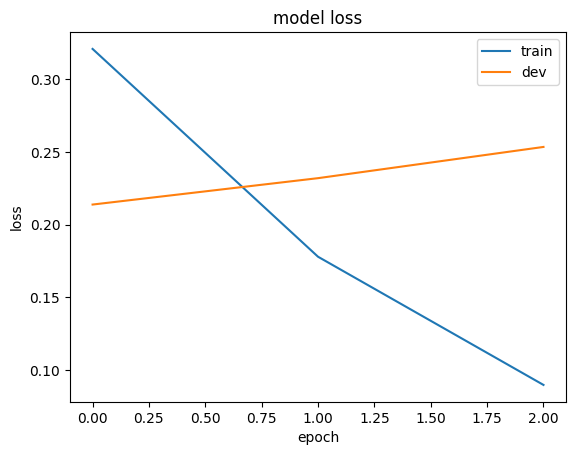

In [57]:
def training_history(history):
    %matplotlib inline
    import matplotlib.pyplot as plt



    # summarize history for loss
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'dev'], loc='upper right')
    plt.show()

training_history(history_3)

313/313 [==============================] - 62s 198ms/step


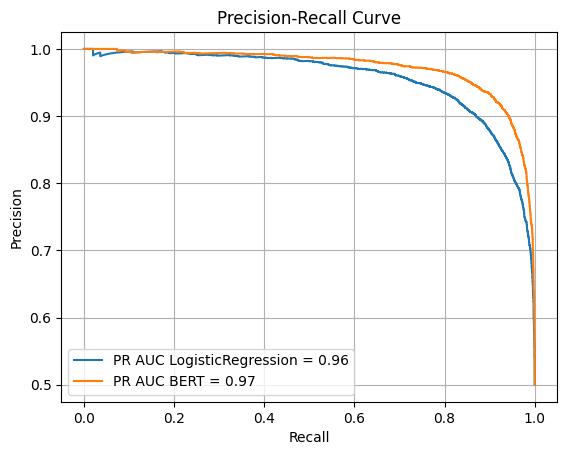

In [65]:
# Predict probabilities (Logistic Regression Baseline-1)
probs = clf.predict_proba(X_test_svd)[:, 1]

# Calculate precision and recall
precision, recall, thresholds = precision_recall_curve(y_test, probs)

# Calculate area under the curve (AUC) for PR curve
pr_auc = auc(recall, precision)

# Plot PR curve for baseline model
plt.plot(recall, precision, label=f'PR AUC LogisticRegression = {pr_auc:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)



# Predict probabilities of X_test using BERT
y_pred =  bert_classifier.predict([bert_test['input_ids'], bert_test['attention_mask']])

precision, recall, thresholds = precision_recall_curve(y_test, y_pred)

# Compute PR AUC
pr_auc = auc(recall, precision)

# Plot the PR curve for our model
plt.plot(recall, precision, label='PR AUC BERT = %0.2f' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')




In [63]:
print(y_pred.shape)

(10000, 1)


In [67]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, auc, precision_recall_curve, roc_auc_score

# Calculate predictions for clf
train_preds_clf = clf.predict_proba(X_train_svd)
train_preds_bin_clf = clf.predict(X_train_svd)

dev_preds_clf = clf.predict_proba(X_dev_svd)
dev_preds_bin_clf = clf.predict(X_dev_svd)

test_preds_clf = clf.predict_proba(X_test_svd)
test_preds_bin_clf = clf.predict(X_test_svd)




# Calculate predictions for BERT
# predict train data
train_preds_bert = bert_classifier.predict([bert_train['input_ids'], bert_train['attention_mask']])
train_preds_bin_bert = np.array([[1] if pred >= 0.5 else [0] for pred in train_preds_bert])

# predict dev data
dev_preds_bert = bert_classifier.predict([bert_val['input_ids'], bert_val['attention_mask']])
dev_preds_bin_bert = np.array([[1] if pred >= 0.5 else [0] for pred in dev_preds_bert])

# predict test data
test_preds_bert = bert_classifier.predict([bert_test['input_ids'], bert_test['attention_mask']])
test_preds_bin_bert = np.array([[1] if pred >= 0.5 else [0] for pred in test_preds_bert])



313/313 [==============================] - 63s 200ms/step


In [69]:
from operator import pos
from sklearn.metrics import precision_recall_curve, average_precision_score

# Define a function to calculate metrics for each class including PR-AUC for MLP
def calculate_class_metrics_model(y_true, y_pred, y_probs):
    report = classification_report(y_true, y_pred, output_dict=True)
    # For class 1
    class_0_metrics = report['0']
    # For class 2
    class_1_metrics = report['1']

    # Calculate PR-AUC for each class
    precision, recall, _ = precision_recall_curve(y_true, y_probs, pos_label=1)
    pr_auc_class_1 = auc(recall, precision)

    # Its binary problem so 1-probability is the probability for class 0
    y_probs = 1-y_probs
    precision, recall, _ = precision_recall_curve(y_true, y_probs, pos_label=0)
    pr_auc_class_0 = auc(recall, precision)

    return class_0_metrics, class_1_metrics, pr_auc_class_0, pr_auc_class_1

# Define a function to calculate metrics for each class including PR-AUC for Logistic
def calculate_class_metrics_clf(y_true, y_pred, y_probs):
    report = classification_report(y_true, y_pred, output_dict=True)
    class_0_metrics = report['0']
    class_1_metrics = report['1']

    # Calculate PR-AUC for each class
    precision, recall, _ = precision_recall_curve(y_true, y_probs[:, 1],pos_label=1)
    pr_auc_class_1 = auc(recall, precision)

    precision, recall, _ = precision_recall_curve(y_true, y_probs[:, 0],pos_label=0)
    pr_auc_class_0 = auc(recall, precision)

    return class_0_metrics, class_1_metrics, pr_auc_class_0, pr_auc_class_1



# Calculate class metrics for clf
class_0_metrics_train_clf, class_1_metrics_train_clf, pr_auc_0_train_clf, pr_auc_1_train_clf = calculate_class_metrics_clf(y_train, train_preds_bin_clf, train_preds_clf)
class_0_metrics_dev_clf, class_1_metrics_dev_clf, pr_auc_0_dev_clf, pr_auc_1_dev_clf = calculate_class_metrics_clf(y_dev, dev_preds_bin_clf, dev_preds_clf)
class_0_metrics_test_clf, class_1_metrics_test_clf, pr_auc_0_test_clf, pr_auc_1_test_clf = calculate_class_metrics_clf(y_test, test_preds_bin_clf, test_preds_clf)

# Calculate class metrics for BERT
class_0_metrics_train_biGRU, class_1_metrics_train_biGRU, pr_auc_0_train_biGRU, pr_auc_1_train_biGRU = calculate_class_metrics_model(y_train, train_preds_bin_bert, train_preds_bert)
class_0_metrics_dev_biGRU, class_1_metrics_dev_biGRU, pr_auc_0_dev_biGRU, pr_auc_1_dev_biGRU = calculate_class_metrics_model(y_dev, dev_preds_bin_bert, dev_preds_bert)
class_0_metrics_test_biGRU, class_1_metrics_test_biGRU, pr_auc_0_test_biGRU, pr_auc_1_test_biGRU = calculate_class_metrics_model(y_test, test_preds_bin_bert,test_preds_bert)


# Create separate DataFrames for training, development, and test results for each class
train_class_metrics_df = pd.DataFrame({
    'Classifier': ['LR','BERT'],
    'Class 0 Precision': [class_0_metrics_train_clf['precision'],class_0_metrics_train_biGRU['precision']],
    'Class 1 Precision': [class_1_metrics_train_clf['precision'],class_1_metrics_train_biGRU['precision']],
    'Class 0 Recall': [class_0_metrics_train_clf['recall'],class_0_metrics_train_biGRU['recall']],
    'Class 1 Recall': [class_1_metrics_train_clf['recall'],class_1_metrics_train_biGRU['recall']],
    'Class 0 F1-score': [class_0_metrics_train_clf['f1-score'], class_0_metrics_train_biGRU['f1-score']],
    'Class 1 F1-score': [class_1_metrics_train_clf['f1-score'], class_1_metrics_train_biGRU['f1-score']],
    'PR AUC Class 0': [pr_auc_0_train_clf,pr_auc_0_train_biGRU],
    'PR AUC Class 1': [pr_auc_1_train_clf,pr_auc_1_train_biGRU]
})

dev_class_metrics_df = pd.DataFrame({
    'Classifier': ['LR', 'BERT'],
    'Class 0 Precision': [class_0_metrics_dev_clf['precision'],class_0_metrics_dev_biGRU['precision']],
    'Class 1 Precision': [class_1_metrics_dev_clf['precision'], class_1_metrics_dev_biGRU['precision']],
    'Class 0 Recall': [class_0_metrics_dev_clf['recall'], class_0_metrics_dev_biGRU['recall']],
    'Class 1 Recall': [class_1_metrics_dev_clf['recall'], class_1_metrics_dev_biGRU['recall']],
    'Class 0 F1-score': [class_0_metrics_dev_clf['f1-score'], class_0_metrics_dev_biGRU['f1-score']],
    'Class 1 F1-score': [class_1_metrics_dev_clf['f1-score'], class_1_metrics_dev_biGRU['f1-score']],
    'PR AUC Class 0': [pr_auc_0_dev_clf, pr_auc_0_dev_biGRU],
    'PR AUC Class 1': [pr_auc_1_dev_clf, pr_auc_1_dev_biGRU]
})

test_class_metrics_df = pd.DataFrame({
    'Classifier': ['LR', 'BERT'],
    'Class 0 Precision': [class_0_metrics_test_clf['precision'],class_0_metrics_test_biGRU['precision']],
    'Class 1 Precision': [class_1_metrics_test_clf['precision'], class_1_metrics_test_biGRU['precision']],
    'Class 0 Recall': [class_0_metrics_test_clf['recall'],class_1_metrics_test_biGRU['recall']],
    'Class 1 Recall': [class_1_metrics_test_clf['recall'], class_1_metrics_test_biGRU['recall']],
    'Class 0 F1-score': [class_0_metrics_test_clf['f1-score'],class_1_metrics_test_biGRU['f1-score']],
    'Class 1 F1-score': [class_1_metrics_test_clf['f1-score'], class_1_metrics_test_biGRU['f1-score']],
    'PR AUC Class 0': [pr_auc_0_test_clf, pr_auc_0_test_biGRU],
    'PR AUC Class 1': [pr_auc_1_test_clf, pr_auc_0_test_biGRU]
})

from tabulate import tabulate

# Print training class metrics
print("Training Class Metrics:")
print(tabulate(train_class_metrics_df, headers='keys', tablefmt='psql'))

# Print development class metrics
print("\nDevelopment Class Metrics:")
print(tabulate(dev_class_metrics_df, headers='keys', tablefmt='psql'))

# Print test class metrics
print("\nTest Class Metrics:")
print(tabulate(test_class_metrics_df, headers='keys', tablefmt='psql'))


Training Class Metrics:
+----+--------------+---------------------+---------------------+------------------+------------------+--------------------+--------------------+------------------+------------------+
|    | Classifier   |   Class 0 Precision |   Class 1 Precision |   Class 0 Recall |   Class 1 Recall |   Class 0 F1-score |   Class 1 F1-score |   PR AUC Class 0 |   PR AUC Class 1 |
|----+--------------+---------------------+---------------------+------------------+------------------+--------------------+--------------------+------------------+------------------|
|  0 | LR           |            0.904421 |            0.887736 |         0.885303 |         0.906492 |           0.89476  |           0.897016 |         0.962402 |         0.960518 |
|  1 | BERT         |            0.93945  |            0.955224 |         0.955988 |         0.938416 |           0.947647 |           0.946746 |         0.986754 |         0.98487  |
+----+--------------+---------------------+-------------

In [70]:
from sklearn.metrics import precision_recall_curve, average_precision_score, precision_score, recall_score, f1_score, auc
import pandas as pd

def calculate_metrics(y_true, y_pred, y_probs):
    precision = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    precision_auc, recall_auc, _ = precision_recall_curve(y_true, y_probs)
    pr_auc = auc(recall_auc, precision_auc)
    return precision, recall, f1, pr_auc

# Calculate class metrics for clf
precision_train_clf, recall_train_clf, f1_train_clf, pr_auc_train_clf = calculate_metrics(y_train, train_preds_bin_clf, train_preds_clf[:,1])
precision_dev_clf, recall_dev_clf, f1_dev_clf, pr_auc_dev_clf = calculate_metrics(y_dev, dev_preds_bin_clf, dev_preds_clf[:,1])
precision_test_clf, recall_test_clf, f1_test_clf, pr_auc_test_clf = calculate_metrics(y_test, test_preds_bin_clf, test_preds_clf[:,1])


# Calculate class metrics for biGRU
precision_train_biGRU, recall_train_biGRU, f1_train_biGRU, pr_auc_train_biGRU = calculate_metrics(y_train, train_preds_bin_bert, train_preds_bert)
precision_dev_biGRU, recall_dev_biGRU, f1_dev_biGRU, pr_auc_dev_biGRU = calculate_metrics(y_dev, dev_preds_bin_bert, dev_preds_bert)
precision_test_biGRU, recall_test_biGRU, f1_test_biGRU, pr_auc_test_biGRU = calculate_metrics(y_test, test_preds_bin_bert,test_preds_bert)




# Create separate DataFrames for training, development, and test results for each class
train_class_metrics_df = pd.DataFrame({
    'Classifier': ['LR', 'BERT'],
    'Precision': [precision_train_clf, precision_train_biGRU],
    'Recall': [recall_train_clf, recall_train_biGRU],
    'F1': [f1_train_clf, f1_train_biGRU],
    'PR AUC': [pr_auc_train_clf,pr_auc_train_biGRU]
})

dev_class_metrics_df = pd.DataFrame({
    'Classifier': ['LR', 'BERT'],
    'Precision': [precision_train_clf,precision_dev_biGRU],
    'Recall': [recall_dev_clf,recall_dev_biGRU],
    'F1': [f1_dev_clf, f1_dev_biGRU],
    'PR AUC': [pr_auc_dev_clf,pr_auc_dev_biGRU]
})

test_class_metrics_df = pd.DataFrame({
    'Classifier': ['LR', 'BERT'],
    'Precision': [precision_test_clf, precision_test_biGRU],
    'Recall': [recall_test_clf, recall_test_biGRU],
    'F1': [f1_test_clf, f1_test_biGRU],
    'PR AUC': [pr_auc_test_clf,pr_auc_test_biGRU]
})

from tabulate import tabulate

# Print training class metrics
print("Training Class Metrics:")
print(tabulate(train_class_metrics_df, headers='keys', tablefmt='psql'))

# Print development class metrics
print("\nDevelopment Class Metrics:")
print(tabulate(dev_class_metrics_df, headers='keys', tablefmt='psql'))

# Print test class metrics
print("\nTest Class Metrics:")
print(tabulate(test_class_metrics_df, headers='keys', tablefmt='psql'))


Training Class Metrics:
+----+--------------+-------------+----------+----------+----------+
|    | Classifier   |   Precision |   Recall |       F1 |   PR AUC |
|----+--------------+-------------+----------+----------+----------|
|  0 | LR           |    0.896079 | 0.895897 | 0.895888 | 0.960518 |
|  1 | BERT         |    0.947337 | 0.947202 | 0.947196 | 0.98487  |
+----+--------------+-------------+----------+----------+----------+

Development Class Metrics:
+----+--------------+-------------+----------+----------+----------+
|    | Classifier   |   Precision |   Recall |       F1 |   PR AUC |
|----+--------------+-------------+----------+----------+----------|
|  0 | LR           |    0.896079 | 0.888947 | 0.888974 | 0.956352 |
|  1 | BERT         |    0.914777 | 0.914736 | 0.914699 | 0.970532 |
+----+--------------+-------------+----------+----------+----------+

Test Class Metrics:
+----+--------------+-------------+----------+----------+----------+
|    | Classifier   |   Precis